# Phase 5 — Model Evaluation
Confusion matrix, ROC curve, PR curve, and threshold sensitivity
on the held-out test set.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
ROOT = Path("..")

with open(ROOT / "models/evaluation_report_v1.json") as f:
    eval_report = json.load(f)

curves = np.load(ROOT / "models/roc_pr_curves_v1.npz")
threshold_df = pd.read_csv(ROOT / "models/threshold_sensitivity_v1.csv")

print(f"Test samples : {eval_report['test_samples']}")
print(f"ROC AUC      : {eval_report['roc_auc']:.4f}")
print(f"Avg Precision: {eval_report['average_precision']:.4f}")

Test samples : 1500
ROC AUC      : 0.8947
Avg Precision: 0.8499


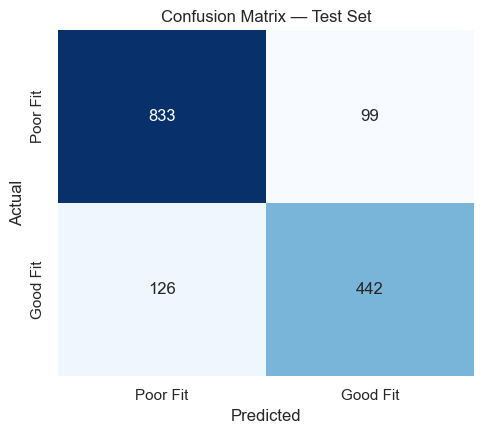

In [2]:
cm = np.array(eval_report["confusion_matrix"])

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Poor Fit", "Good Fit"],
            yticklabels=["Poor Fit", "Good Fit"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig(ROOT / "screenshots/confusion_matrix.png", dpi=150)
plt.show()

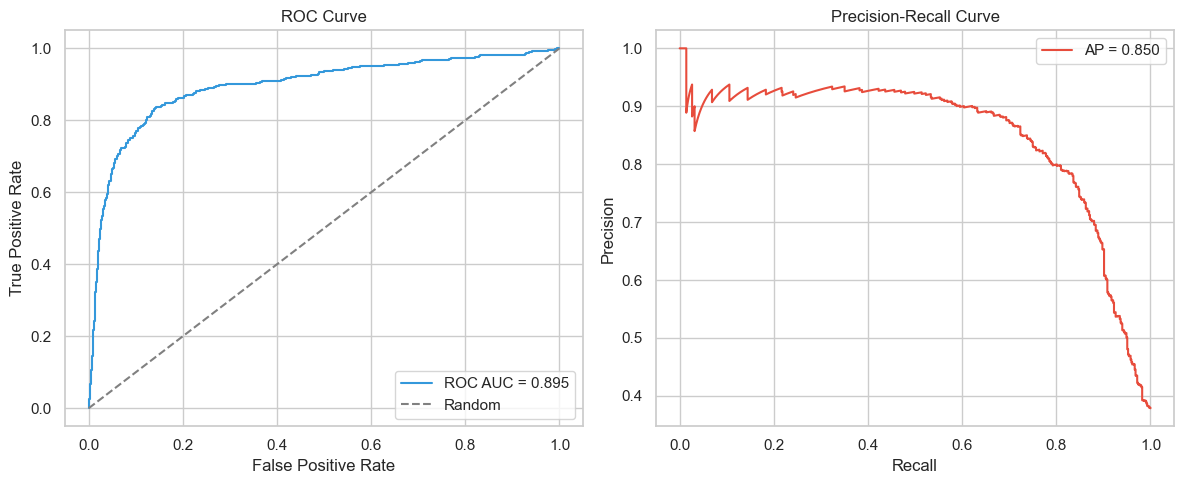

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
axes[0].plot(curves["fpr"], curves["tpr"], color="#3498db",
             label=f"ROC AUC = {eval_report['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

# PR
axes[1].plot(curves["recall"], curves["precision"], color="#e74c3c",
             label=f"AP = {eval_report['average_precision']:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(ROOT / "screenshots/roc_pr_curves.png", dpi=150)
plt.show()

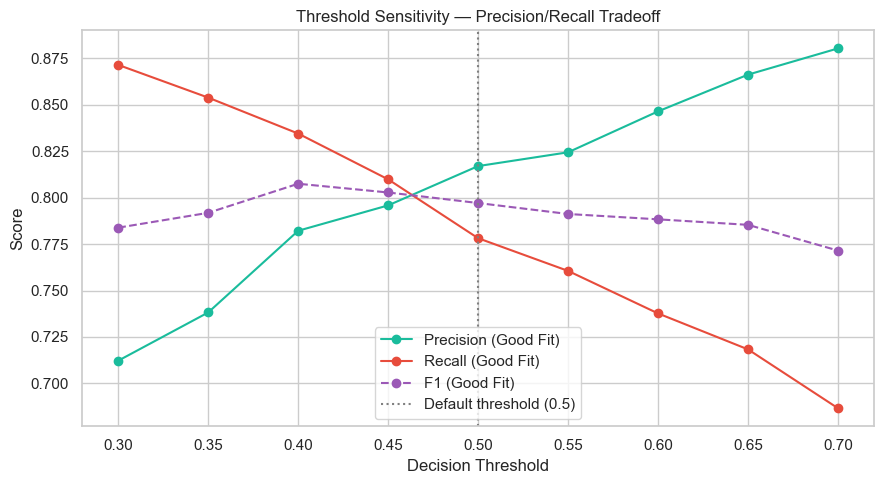

,threshold,precision_good_fit,recall_good_fit,f1_good_fit,accuracy
0,0.30,0.712230,0.871479,0.783848,0.818000
1,0.35,0.738204,0.853873,0.791837,0.830000
2,0.40,0.782178,0.834507,0.807496,0.849333
3,0.45,0.795848,0.809859,0.802792,0.849333
4,0.50,0.817006,0.778169,0.797115,0.850000
5,0.55,0.824427,0.760563,0.791209,0.848000
6,0.60,0.846465,0.737676,0.788335,0.850000
7,0.65,0.866242,0.718310,0.785371,0.851333
8,0.70,0.880361,0.686620,0.771513,0.846000


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df["threshold"], threshold_df["precision_good_fit"],
        marker="o", label="Precision (Good Fit)", color="#1abc9c")
ax.plot(threshold_df["threshold"], threshold_df["recall_good_fit"],
        marker="o", label="Recall (Good Fit)", color="#e74c3c")
ax.plot(threshold_df["threshold"], threshold_df["f1_good_fit"],
        marker="o", label="F1 (Good Fit)", color="#9b59b6", linestyle="--")
ax.axvline(0.5, color="gray", linestyle=":", label="Default threshold (0.5)")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Sensitivity — Precision/Recall Tradeoff")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "screenshots/threshold_sensitivity.png", dpi=150)
plt.show()

threshold_df

In [5]:
report_df = pd.DataFrame(eval_report["classification_report"]).T.round(3)
report_df

,precision,recall,f1-score,support
Poor Fit,0.869,0.894,0.881,932.00
Good Fit,0.817,0.778,0.797,568.00
accuracy,0.850,0.850,0.850,0.85
macro avg,0.843,0.836,0.839,1500.00
weighted avg,0.849,0.850,0.849,1500.00
